# Extraccion de caracteristicas

In [1]:
# Cargar los datos transformados
import os
from os import path
import numpy as np
from pathlib import Path

STFT_PATH = './data/tf_representations/stft.npz'
CWT_PATH  = './data/tf_representations/cwt.npz'
#GSP_PATH  = './data/tf_representations/gsp.npz'

CHANNELS   = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
TARGET_COL = 'eyeDetection'  # 0: ojos abiertos, 1: ojos cerrados

#lista = [('STFT', STFT_PATH), ('CWT', CWT_PATH), ('GSP', GSP_PATH)]
lista = [('STFT', STFT_PATH), ('CWT', CWT_PATH)]

for label, fpath in lista:
    if not path.exists(fpath):
        raise FileNotFoundError(f"El archivo no existe: {fpath}")
    else:
        print(f"Los datos {label} ya existen en {fpath}")

stft = np.load(STFT_PATH)
cwt  = np.load(CWT_PATH)
#gsp  = np.load(GSP_PATH, allow_pickle=True)

print(f"\nSTFT — Shape por canal : {stft['O2'].shape}  |  Canales: {len(CHANNELS)}")
print(f"CWT  — Shape por canal : {cwt['O2'].shape}   |  Canales: {len(CHANNELS)}")
#print(f"GSP  — Shape espectrograma: {gsp['spectrogram'].shape}  (modos × tiempo)")

print(f"\nLabels STFT: {stft['labels'].shape}  |  Clases: {np.unique(stft['labels'])}")
print(f"Labels CWT : {cwt['labels'].shape}   |  Clases: {np.unique(cwt['labels'])}")
#print(f"Labels GSP : {gsp['labels'].shape}   |  Clases: {np.unique(gsp['labels'])}")

stft_freqs = stft['freqs']
stft_times = stft['times']
cwt_freqs  = cwt['freqs']
cwt_times  = cwt['times']

Los datos STFT ya existen en ./data/tf_representations/stft.npz
Los datos CWT ya existen en ./data/tf_representations/cwt.npz

STFT — Shape por canal : (73, 236)  |  Canales: 14
CWT  — Shape por canal : (80, 14980)   |  Canales: 14

Labels STFT: (236,)  |  Clases: [0. 1.]
Labels CWT : (14980,)   |  Clases: [0 1]


## Consideraciones y definiciones iniciales

- **Alineación temporal**: La STFT ya tiene sus propias ventanas de 2s (~232 ventanas en stft_times). Para que la comparación sea justa, la CWT debe analizar exactamente los mismos segmentos temporales. Para cada ventana STFT centrada en t_i, calculo los índices de muestra correspondientes en la CWT y promedio la potencia en ese eje temporal, obteniendo un espectro promedio (80,). Ambas representaciones producen así el mismo número de instancias con las mismas etiquetas.
- **Integración trapezoidal**: Las frecuencias de la STFT son linealmente espaciadas y las de la CWT son log-espaciadas. Si sumamos directamente los valores de potencia sin ponderar vamos a sobrepasar las frecuencias bajas en la CWT. `np.trapezoid(power, freqs)` maneja ambos casos correctamente.
- **Origen de frecuencias CWT**: Según como se construyeron las escalas en el notebook anterior, las frecuencias de la CWT pueden estar en orden descendente. Hay una función auxiliar que lo detecta y corrige antes de integrar.

## Decisiones de diseño — extracción de features

### Features seleccionadas (4 por canal × 14 canales = 56 features)

Para cada ventana temporal y cada canal EEG se extraen cuatro características
desde el espectro de potencia promediado:

1. **Potencia alfa absoluta** (`alpha_abs`): integral trapezoidal de la densidad
   de potencia en 8–13 Hz. Cuantifica la energía bruta del ritmo alfa. Se usa
   integración trapezoidal (`np.trapz`) en lugar de suma directa para manejar
   correctamente frecuencias no uniformemente espaciadas (CWT log-espaciada).

2. **Potencia alfa relativa** (`alpha_rel`): cociente entre la potencia alfa y la
   potencia total en 4–40 Hz. Al normalizar por la potencia total, esta feature
   es invariante a diferencias de amplitud entre sujetos y sesiones — un requisito
   importante para comparaciones justas entre técnicas TF con distintas unidades.

3. **Entropía espectral de Shannon normalizada** (`entropy`): mide cuán
   concentrada está la energía en el espectro completo (4–40 Hz). Un valor bajo
   indica que la energía se concentra en pocas frecuencias (ej. alfa dominante);
   un valor alto indica distribución uniforme (ausencia de ritmo dominante).
   Se normaliza por $\log_2(N)$ para que el rango sea siempre $[0, 1]$
   independientemente del número de bins de frecuencia, permitiendo comparación
   directa entre STFT (espaciado lineal) y CWT (espaciado logarítmico).

4. **Centro de gravedad alfa** (`cog`): media ponderada de las frecuencias en
   8–13 Hz, con la potencia como peso — método de Klimesch (1999). Más robusto
   que el pico máximo porque no asume que el alfa tiene un único pico, lo cual
   no siempre se cumple empíricamente.

### Rango de frecuencias

Ambas representaciones cubren 4–40 Hz, alineado con el filtro pasa-banda
aplicado en el preprocesamiento. La banda delta (< 4 Hz) se excluye porque
no es fisiológicamente relevante para la tarea de ojos abiertos/cerrados.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# ------------------------- CONSTANTES -------------------------
# --------------------------------------------------------------

FS          = 128    # Hz
ALPHA_LO    = 8.0    # Hz — límite inferior banda alfa
ALPHA_HI    = 13.0   # Hz — límite superior banda alfa
WIN_SEC     = 4.0    # s  — largo de ventana (bloques sostenidos)
MIN_BLK_SEC = 4.0    # s  — duración mínima de un bloque para ser considerado
WIN_SAMPLES = int(WIN_SEC * FS)   # 512 muestras
MIN_BLK_SAM = int(MIN_BLK_SEC * FS)  # 512 muestras

FEAT_NAMES = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']
COL_NAMES  = [f'{ch}_{f}' for ch in CHANNELS for f in FEAT_NAMES]

### Funciones de Extracción

In [3]:
def _sort_asc(power, freqs):
    """Reordena ascendentemente si las frecuencias vienen descendentes (CWT)."""
    if freqs[0] > freqs[-1]:
        idx = np.argsort(freqs)
        return power[idx], freqs[idx]
    return power, freqs


def alpha_power_abs(power, freqs):
    """Potencia absoluta en la banda alfa (integración trapezoidal)."""
    p, f = _sort_asc(power, freqs)
    mask = (f >= ALPHA_LO) & (f <= ALPHA_HI)
    if mask.sum() < 2:
        return 0.0
    return float(np.trapezoid(p[mask], f[mask]))


def alpha_power_rel(power, freqs):
    """Potencia relativa: alfa / total (4-40 Hz). Invariante a escala de amplitud."""
    p, f = _sort_asc(power, freqs)
    p_alpha = alpha_power_abs(p, f)
    p_total = float(np.trapezoid(p, f))
    return p_alpha / p_total if p_total > 0 else 0.0


def spectral_entropy(power):
    """
    Entropía espectral de Shannon normalizada.
    0 → energía concentrada en pocas frecuencias (ej. alfa dominante).
    1 → energía distribuida uniformemente.
    """
    total = power.sum()
    if total <= 0:
        return 0.0
    p = power / total
    p = p[p > 0]                        # evitar log(0)
    H     = -np.sum(p * np.log2(p))
    H_max = np.log2(len(power))         # entropía máxima (distribución uniforme)
    return float(H / H_max) if H_max > 0 else 0.0


def alpha_cog(power, freqs):
    """
    Centro de gravedad (CoG) en la banda alfa — método Klimesch (1999).
    Más robusto que el pico máximo cuando hay picos dobles o ambiguos.
    """
    p, f = _sort_asc(power, freqs)
    mask   = (f >= ALPHA_LO) & (f <= ALPHA_HI)
    p_band = p[mask]
    f_band = f[mask]
    denom  = p_band.sum()
    return float(np.sum(f_band * p_band) / denom) if denom > 0 else (ALPHA_LO + ALPHA_HI) / 2.0

## Estrategia de segmentación — bloques sostenidos

### Motivación

En el notebook anterior se utilizó una ventana deslizante uniforme de 2 s con
75% de solapamiento sobre todo el registro. Ese enfoque produjo features con
baja discriminabilidad entre clases, lo cual se atribuye a dos causas
identificadas durante el diagnóstico:

- **Artefactos de parpadeo**: inyectan energía en el rango 0.5–12 Hz
  contaminando la banda alfa en ambas clases por igual.
- **Ventanas de transición**: con cambios de estado frecuentes en el registro,
  muchas ventanas abarcan períodos mixtos, recibiendo una etiqueta ambigua.

### Segmentación por bloques sostenidos

Para mitigar ambos problemas se adopta la siguiente estrategia: se identifican
en la señal original todos los períodos en que el estado ocular se mantiene
**constante durante al menos 4 s** (512 muestras). Solo esos bloques participan
en la extracción de features. Los períodos cortos y las transiciones se descartan.

Dentro de cada bloque sostenido se extraen ventanas de 4 s **sin solapamiento**,
garantizando que las instancias resultantes sean temporalmente independientes
entre sí. Esto evita el data leakage que generaba el solapamiento del 75% y
permite usar un split aleatorio estándar en la etapa de clasificación.

### Alineación entre STFT y CWT

Ambas representaciones se segmentan sobre los mismos bloques y con los mismos
límites temporales:

- **CWT** (resolución de muestra): se promedia la potencia directamente en el
  rango de muestras $[\text{w\_start},\ \text{w\_end}]$ de cada ventana.
- **STFT** (resolución de frame ~0.5 s): se identifican los frames cuyos tiempos
  centrales caen dentro de la ventana y se promedia su espectro.

Ambas producen el mismo número de instancias con las mismas etiquetas, condición
necesaria para que la comparación sea justa.

### Etiquetado

Cada ventana hereda directamente la etiqueta del bloque al que pertenece. Como
el bloque es por definición homogéneo (mismo estado durante toda su duración),
no existe ambigüedad en el etiquetado.

In [4]:
def find_sustained_blocks(labels, min_samples):
    """
    Encuentra bloques contiguos de cada clase que duren al menos min_samples.

    Recorre la secuencia de etiquetas y agrupa muestras consecutivas con el
    mismo valor. Solo retorna los bloques cuya duración supera el umbral,
    descartando períodos cortos y de transición.

    Parámetros
    ----------
    labels      : ndarray (N,) — etiqueta por muestra (0 o 1)
    min_samples : int          — mínimo de muestras para aceptar el bloque

    Retorna
    -------
    blocks : list de (start, end, label)
             start/end son índices de muestra inclusivos
    """
    blocks = []
    i = 0
    while i < len(labels):
        current = labels[i]
        j = i
        # Avanzar mientras la etiqueta no cambie
        while j < len(labels) and labels[j] == current:
            j += 1
        duration = j - i
        if duration >= min_samples:
            blocks.append((i, j - 1, int(current)))
        i = j
    return blocks


# Cargar etiquetas originales (resolución de muestra)
import pandas as pd
df_orig     = pd.read_csv('./data/eeg_eye_state_clean.csv')
orig_labels = df_orig['eyeDetection'].values   # (14980,)

blocks = find_sustained_blocks(orig_labels, MIN_BLK_SAM)

print(f"Bloques sostenidos encontrados (>= {MIN_BLK_SEC}s): {len(blocks)}")
print(f"  Clase 0 (ojos abiertos): {sum(1 for _,_,l in blocks if l==0)} bloques")
print(f"  Clase 1 (ojos cerrados): {sum(1 for _,_,l in blocks if l==1)} bloques")

# Cuántas ventanas no solapadas caben en total
total_windows = sum((e - s + 1) // WIN_SAMPLES for s, e, _ in blocks)
print(f"\nVentanas de {WIN_SEC}s sin solapamiento: {total_windows} en total")

Bloques sostenidos encontrados (>= 4.0s): 12
  Clase 0 (ojos abiertos): 7 bloques
  Clase 1 (ojos cerrados): 5 bloques

Ventanas de 2.0s sin solapamiento: 42 en total


### STFT

In [5]:
# Para la STFT (resolución de frame ~0.5s), identificamos los frames
# que caen dentro de cada ventana de bloque y promediamos su espectro.
# Esto es necesario porque la STFT no tiene resolución de muestra.

rows_stft  = []
labels_blk = []

for blk_start, blk_end, blk_label in blocks:
    # Tiempo absoluto de inicio y fin del bloque
    t_blk_start = blk_start / FS
    t_blk_end   = blk_end   / FS

    # Extraer ventanas no solapadas dentro del bloque
    w_start_sam = blk_start
    while w_start_sam + WIN_SAMPLES - 1 <= blk_end:
        w_end_sam = w_start_sam + WIN_SAMPLES - 1
        t_w_start = w_start_sam / FS
        t_w_end   = w_end_sam   / FS

        # Frames STFT que caen dentro de esta ventana
        frame_mask = (stft_times >= t_w_start) & (stft_times <= t_w_end)

        if frame_mask.sum() == 0:
            w_start_sam += WIN_SAMPLES
            continue

        row = {}
        for ch in CHANNELS:
            # Promedio de frames dentro de la ventana → espectro (n_freqs,)
            spectrum = stft[ch][:, frame_mask].mean(axis=1)
            row[f'{ch}_alpha_abs'] = alpha_power_abs(spectrum, stft_freqs)
            row[f'{ch}_alpha_rel'] = alpha_power_rel(spectrum, stft_freqs)
            row[f'{ch}_entropy']   = spectral_entropy(spectrum)
            row[f'{ch}_cog']       = alpha_cog(spectrum, stft_freqs)

        rows_stft.append(row)
        labels_blk.append(blk_label)
        w_start_sam += WIN_SAMPLES   # sin solapamiento

df_stft_feat = pd.DataFrame(rows_stft, columns=COL_NAMES)
df_stft_feat['label'] = labels_blk

print(f"STFT — shape: {df_stft_feat.shape}")
print(f"  NaN: {df_stft_feat.isnull().sum().sum()}")
print(f"  Clases: {df_stft_feat['label'].value_counts().to_dict()}")

STFT — shape: (42, 57)
  NaN: 0
  Clases: {0: 23, 1: 19}


### CWT

In [6]:
# Para la CWT (resolución de muestra), promediamos directamente
# la potencia en el rango de muestras de cada ventana.

rows_cwt = []

for blk_start, blk_end, blk_label in blocks:
    w_start_sam = blk_start
    while w_start_sam + WIN_SAMPLES - 1 <= blk_end:
        w_end_sam = w_start_sam + WIN_SAMPLES - 1

        row = {}
        for ch in CHANNELS:
            # Promedio temporal dentro de la ventana → espectro (n_freqs,)
            spectrum = cwt[ch][:, w_start_sam : w_end_sam + 1].mean(axis=1)
            row[f'{ch}_alpha_abs'] = alpha_power_abs(spectrum, cwt_freqs)
            row[f'{ch}_alpha_rel'] = alpha_power_rel(spectrum, cwt_freqs)
            row[f'{ch}_entropy']   = spectral_entropy(spectrum)
            row[f'{ch}_cog']       = alpha_cog(spectrum, cwt_freqs)

        rows_cwt.append(row)
        w_start_sam += WIN_SAMPLES   # sin solapamiento

df_cwt_feat = pd.DataFrame(rows_cwt, columns=COL_NAMES)
df_cwt_feat['label'] = labels_blk   # mismos bloques → mismas etiquetas

print(f"CWT — shape: {df_cwt_feat.shape}")
print(f"  NaN: {df_cwt_feat.isnull().sum().sum()}")
print(f"  Clases: {df_cwt_feat['label'].value_counts().to_dict()}")

CWT — shape: (42, 57)
  NaN: 0
  Clases: {0: 23, 1: 19}


## Revisión

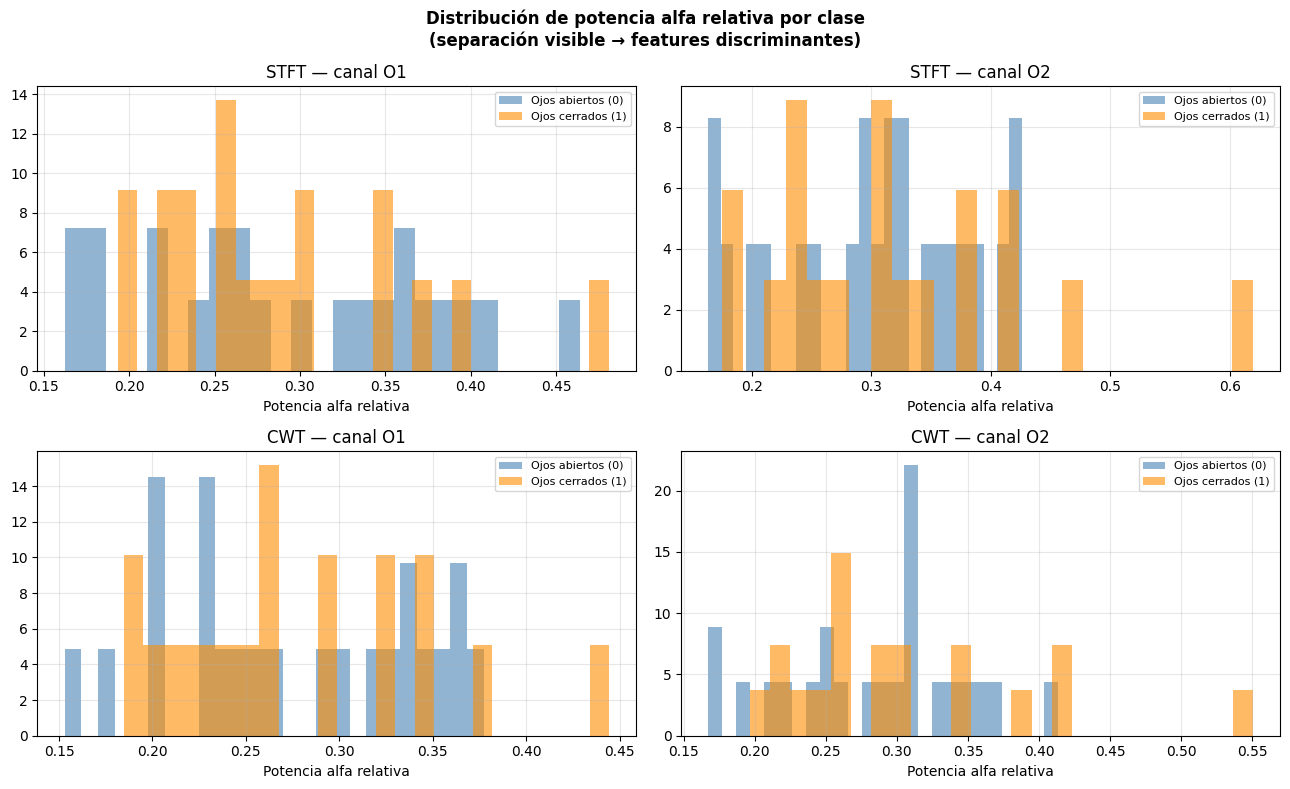


STFT — media potencia alfa relativa en O1:
  Clase 0: 0.2939
  Clase 1: 0.2879

CWT — media potencia alfa relativa en O1:
  Clase 0: 0.2769
  Clase 1: 0.2767


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=False)

for row_i, (method, df_feat) in enumerate([('STFT', df_stft_feat), ('CWT', df_cwt_feat)]):
    for col_j, ch in enumerate(['O1', 'O2']):
        ax = axes[row_i, col_j]
        col = f'{ch}_alpha_rel'
        for cls, color, lbl in [(0, 'steelblue', 'Ojos abiertos (0)'),
                                 (1, 'darkorange', 'Ojos cerrados (1)')]:
            vals = df_feat.loc[df_feat['label'] == cls, col]
            ax.hist(vals, bins=25, alpha=0.6, color=color, label=lbl, density=True)
        ax.set_title(f'{method} — canal {ch}')
        ax.set_xlabel('Potencia alfa relativa')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Distribución de potencia alfa relativa por clase\n'
             '(separación visible → features discriminantes)', fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen numérico
for method, df_feat in [('STFT', df_stft_feat), ('CWT', df_cwt_feat)]:
    print(f"\n{method} — media potencia alfa relativa en O1:")
    for cls in [0, 1]:
        m = df_feat.loc[df_feat['label'] == cls, 'O1_alpha_rel'].mean()
        print(f"  Clase {cls}: {m:.4f}")

In [8]:
# Celda de diagnóstico — agregar al notebook
print("=== Verificación del pipeline ===")
print(f"STFT freqs: {stft_freqs.min():.2f} – {stft_freqs.max():.2f} Hz")
print(f"CWT  freqs: {cwt_freqs.min():.2f} – {cwt_freqs.max():.2f} Hz")

# ¿La señal tiene media ~0 como corresponde tras Z-score?
import pandas as pd
df_orig = pd.read_csv('./data/eeg_eye_state_clean.csv')
print(f"\nMedia O1 en señal preprocesada: {df_orig['O1'].mean():.4f}  (esperado: ~0)")
print(f"Std  O1 en señal preprocesada: {df_orig['O1'].std():.4f}   (esperado: ~1)")

# Distribución temporal de etiquetas
labels_all = df_orig['eyeDetection'].values
print(f"\nTotal muestras clase 0: {(labels_all==0).sum()}  ({100*(labels_all==0).mean():.1f}%)")
print(f"Total muestras clase 1: {(labels_all==1).sum()}  ({100*(labels_all==1).mean():.1f}%)")

=== Verificación del pipeline ===
STFT freqs: 4.00 – 40.00 Hz
CWT  freqs: 4.00 – 40.00 Hz

Media O1 en señal preprocesada: 0.0000  (esperado: ~0)
Std  O1 en señal preprocesada: 1.0000   (esperado: ~1)

Total muestras clase 0: 8257  (55.1%)
Total muestras clase 1: 6723  (44.9%)


## Guardado

In [ ]:
output_dir = './data/X_features/'

os.makedirs(output_dir, exist_ok=True)

df_stft_feat.to_csv('./data/features/X_features_stft.csv', index=False)
df_cwt_feat.to_csv('./data/features/X_features_cwt.csv',  index=False)

print(f"Guardado: X_features_stft.csv  — {df_stft_feat.shape}")
print(f"Guardado: X_features_cwt.csv   — {df_cwt_feat.shape}")
print(f"\nColumnas de features: {COL_NAMES[:8]} ... ({len(COL_NAMES)} total + label)")

Guardado: features_stft.csv  — (42, 57)
Guardado: features_cwt.csv   — (42, 57)

Columnas de features: ['AF3_alpha_abs', 'AF3_alpha_rel', 'AF3_entropy', 'AF3_cog', 'F7_alpha_abs', 'F7_alpha_rel', 'F7_entropy', 'F7_cog'] ... (56 total + label)
